<a target="_blank" href="https://colab.research.google.com/github/dcintlab/HS-25-26/blob/master/Summer_camp/GoodFeaturesToTrack.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Good Features to Track (Shi-Tomasi Corner Detection)

This notebook demonstrates how to use OpenCV's `cv2.goodFeaturesToTrack` to detect strong corners in an image.

We will:
- Load an image
- Convert to grayscale
- Detect corners
- Visualize results
- Experiment with parameters


In [35]:
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive/')
    %cd /content/drive/My Drive/HS-25-26
except:
    IN_COLAB = False
    # Updating imports
    %load_ext autoreload
    %autoreload 2
print(f'Running on {"Google colab" if IN_COLAB else "Local computer"}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Running on Local computer


In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(799.5), np.float64(1062.5), np.float64(-0.5))

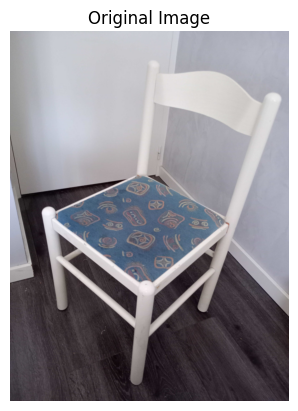

In [37]:
# Load image (replace with your own path)
image = cv2.imread('chair.jpg')


# Convert BGR to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

## Parameters of `cv2.goodFeaturesToTrack`

- `maxCorners`: Maximum number of corners to return
- `qualityLevel`: Minimum quality of corners (0–1)
- `minDistance`: Minimum distance between corners
- `blockSize`: Neighborhood size


(np.float64(-0.5), np.float64(799.5), np.float64(1062.5), np.float64(-0.5))

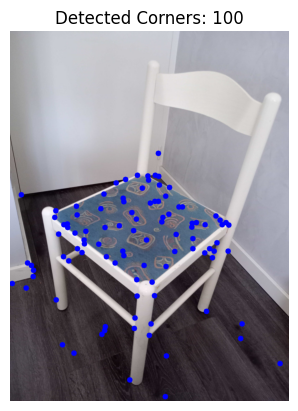

In [38]:
# Parameters
max_corners = 100
quality_level = 0.01
min_distance = 10

corners = cv2.goodFeaturesToTrack(
    gray,
    maxCorners=max_corners,
    qualityLevel=quality_level,
    minDistance=min_distance
)

corners = np.int32(corners)

# Draw corners
output = image_rgb.copy()

for corner in corners:
    x, y = corner.ravel()
    cv2.circle(output, (x, y), 8, (0, 0, 255), -1)

plt.imshow(output)
plt.title(f'Detected Corners: {len(corners)}')
plt.axis('off')

## Experiment: Change Parameters

Try different values to see how detection changes.

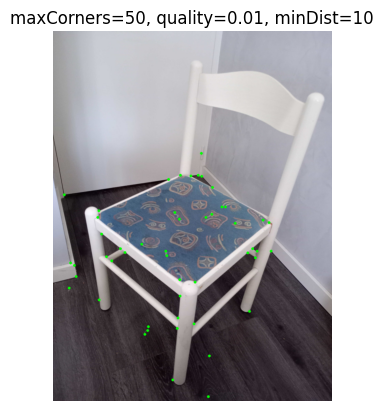

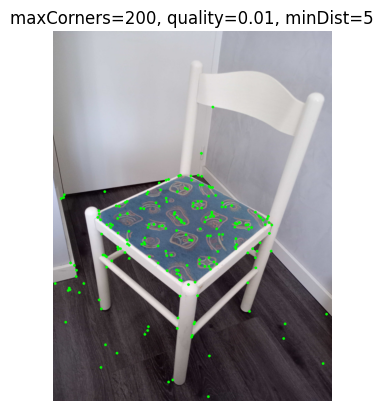

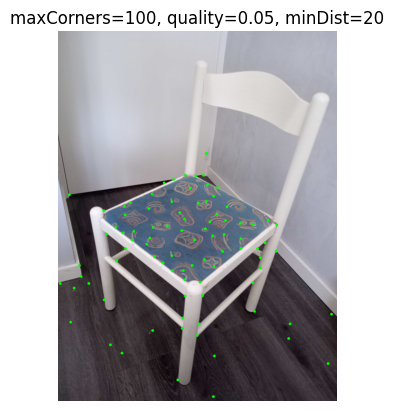

In [39]:
def detect_and_plot(max_corners, quality_level, min_distance):
    corners = cv2.goodFeaturesToTrack(
        gray,
        maxCorners=max_corners,
        qualityLevel=quality_level,
        minDistance=min_distance
    )

    corners = np.int32(corners)
    output = image_rgb.copy()

    for corner in corners:
        x, y = corner.ravel()
        cv2.circle(output, (x, y), 4, (0, 255, 0), -1)

    plt.imshow(output)
    plt.title(f'maxCorners={max_corners}, quality={quality_level}, minDist={min_distance}')
    plt.axis('off')

# Try different settings
detect_and_plot(50, 0.01, 10)
plt.figure()
detect_and_plot(200, 0.01, 5)
plt.figure()
detect_and_plot(100, 0.05, 20)

## How to make circles?
We use this code:

In [40]:
for corner in corners:
    x, y = corner.ravel()
    cv2.circle(output, (x, y), 8, (255, 0, 0), -1)

Imported this function in OpenCV python package cv2

8 is a radius of the circle

(255, 0, 0) are colour code 

(255, 0, 0) are red

(0, 255, 0) are green 

(0, 0, 255) are blue